#1 - Download e extração dos dados

In [2]:
# Baixa o arquivo zip direto do repositório do GitHub
!wget https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip

# Extrai os arquivos silenciosamente (-q) para não poluir a tela
!unzip -q 2020-02-14_InfraredSolarModules.zip

# Mostra o que foi extraído na pasta atual
!ls

--2026-06-06 06:12:24--  https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/RaptorMaps/InfraredSolarModules/master/2020-02-14_InfraredSolarModules.zip [following]
--2026-06-06 06:12:24--  https://raw.githubusercontent.com/RaptorMaps/InfraredSolarModules/master/2020-02-14_InfraredSolarModules.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15495990 (15M) [application/zip]
Saving to: ‘2020-02-14_InfraredSolarModules.zip’

2020-02-14_Infrared 100%[===================>]  14.78M  --.-KB/s    in 0.1s    

#2 - Leitura do JSON e criação do mapeamento

In [3]:
import json
import pandas as pd
import cv2
from matplotlib import pyplot as plt

# Abre e lê o arquivo JSON
with open('InfraredSolarModules/module_metadata.json', 'r') as f:
    metadados = json.load(f)

# Converte o JSON para um DataFrame do Pandas
df = pd.DataFrame.from_dict(metadados, orient='index')

# Mostra as primeiras 5 linhas e os tipos de anomalias pra ver se deu certo
print(df.head())
print("\n")
print(df['anomaly_class'].value_counts())

         image_filepath anomaly_class
13357  images/13357.jpg    No-Anomaly
13356  images/13356.jpg    No-Anomaly
19719  images/19719.jpg    No-Anomaly
11542  images/11542.jpg    No-Anomaly
11543  images/11543.jpg    No-Anomaly


anomaly_class
No-Anomaly        10000
Cell               1877
Vegetation         1639
Diode              1499
Cell-Multi         1288
Shadowing          1056
Cracking            940
Offline-Module      827
Hot-Spot            249
Hot-Spot-Multi      246
Soiling             204
Diode-Multi         175
Name: count, dtype: int64


#3 - Visualização inicial das amostras

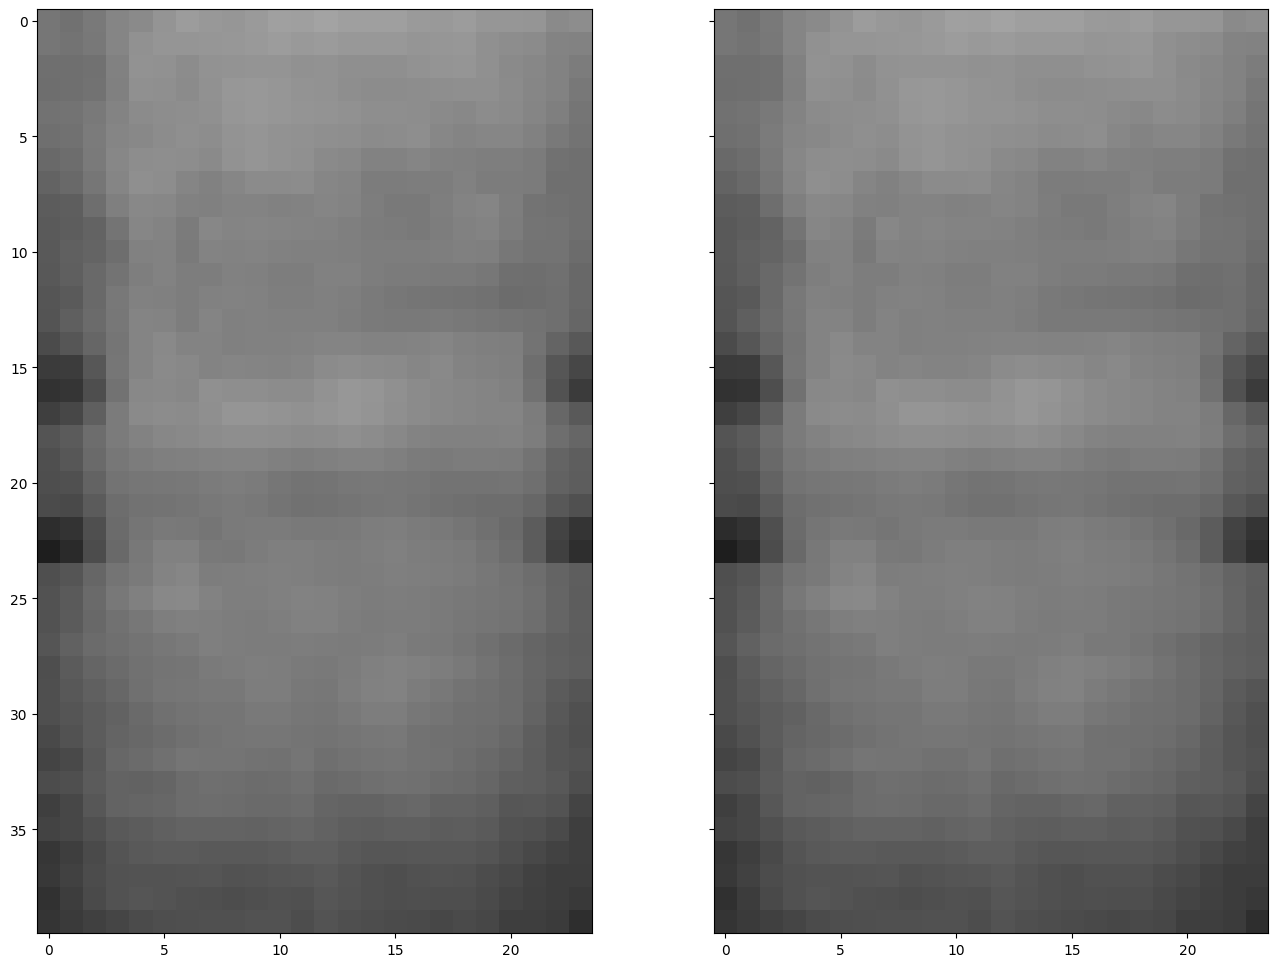

In [ ]:
# Load the image in color (OpenCV standard = BGR)
orig = cv2.imread('InfraredSolarModules/images/0.jpg', cv2.IMREAD_COLOR)
# Convert to RGB
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

# Load the image in grayscale
gray = cv2.imread('InfraredSolarModules/images/0.jpg', cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(16, 12), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(orig, vmin=0, vmax=255)
ax[1].imshow(gray, 'gray', vmin=0, vmax=255)

InfraredSolarModules/images/10473.jpg
No-Anomaly
InfraredSolarModules/images/12309.jpg
No-Anomaly
InfraredSolarModules/images/17397.jpg
No-Anomaly
InfraredSolarModules/images/17892.jpg
No-Anomaly
InfraredSolarModules/images/16441.jpg
No-Anomaly


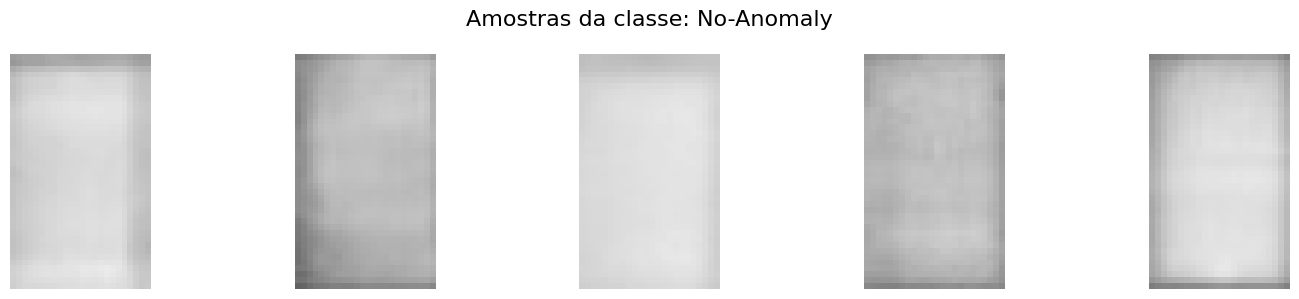

InfraredSolarModules/images/6862.jpg
Hot-Spot
InfraredSolarModules/images/6907.jpg
Hot-Spot
InfraredSolarModules/images/6764.jpg
Hot-Spot
InfraredSolarModules/images/6865.jpg
Hot-Spot
InfraredSolarModules/images/6794.jpg
Hot-Spot


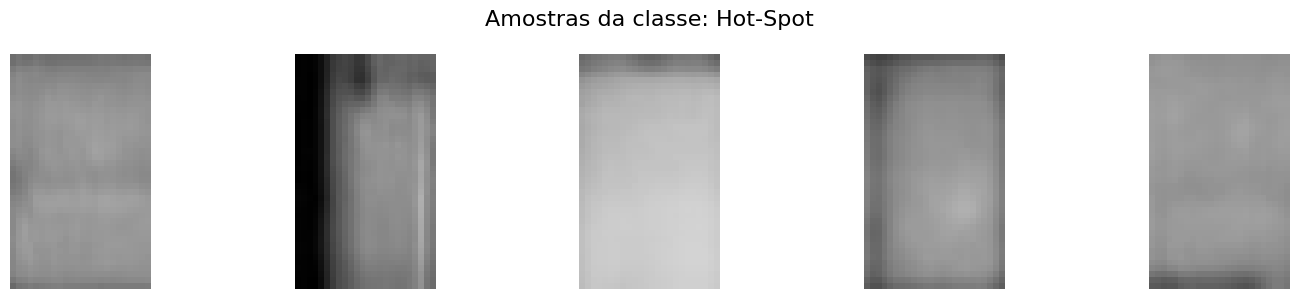

InfraredSolarModules/images/411.jpg
Offline-Module
InfraredSolarModules/images/613.jpg
Offline-Module
InfraredSolarModules/images/178.jpg
Offline-Module
InfraredSolarModules/images/101.jpg
Offline-Module
InfraredSolarModules/images/419.jpg
Offline-Module


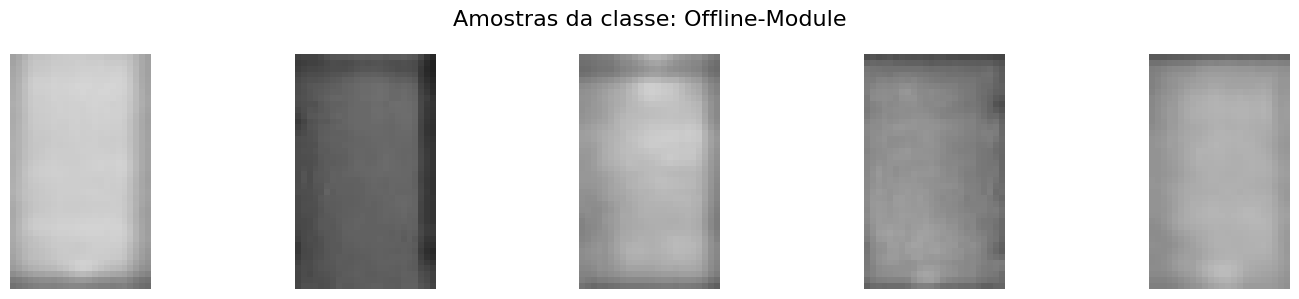

InfraredSolarModules/images/5506.jpg
Cell
InfraredSolarModules/images/6692.jpg
Cell
InfraredSolarModules/images/6103.jpg
Cell
InfraredSolarModules/images/6504.jpg
Cell
InfraredSolarModules/images/5513.jpg
Cell


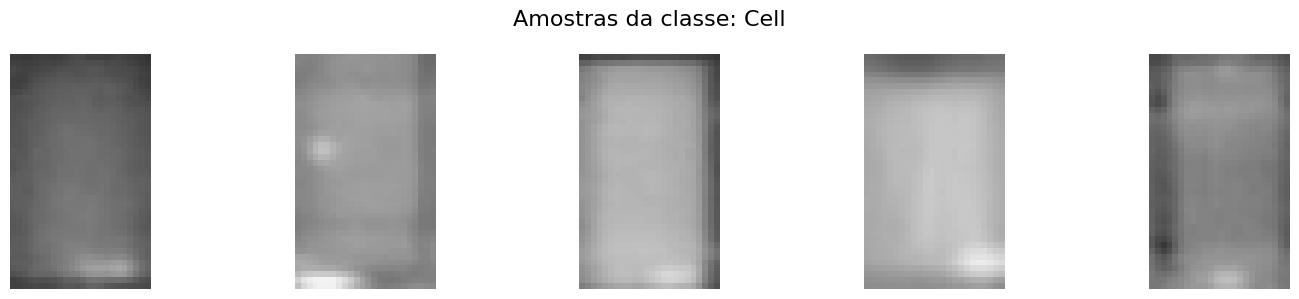

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

def visualizar_amostras(df, classe_nome, num_amostras=5):
    # Filtra a tabela apenas para a classe desejada
    df_filtrado = df[df['anomaly_class'] == classe_nome]

    Pega amostras aleatórias
    amostras = df_filtrado.sample(min(len(df_filtrado), num_amostras))

    fig, axes = plt.subplots(1, num_amostras, figsize=(15, 3))
    fig.suptitle(f"Amostras da classe: {classe_nome}", fontsize=16)

    # Ajuste caso o número de amostras seja 1
    if num_amostras == 1:
        axes = [axes]

    # Pasta raiz onde o zip foi extraído
    pasta_raiz = 'InfraredSolarModules'

    for ax, caminho_imagem in zip(axes, amostras['image_filepath']):
        # Adiciona a pasta raiz no caminho
        caminho_corrigido = os.path.join(pasta_raiz, caminho_imagem)

        # Lê a imagem em tons de cinza
        img = cv2.imread(caminho_corrigido, cv2.IMREAD_GRAYSCALE)

        # se a imagem não for encontrada, avisa e pula
        if img is None:
            ax.set_title("Erro ao carregar")
            ax.axis('off')
            print(f"Aviso: Não foi possível carregar a imagem em {caminho_corrigido}")
            continue

        # Mostra a imagem
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')

        print(caminho_corrigido)
        print(classe_nome)

    plt.tight_layout()
    plt.show()

visualizar_amostras(df, 'No-Anomaly', num_amostras=5)
visualizar_amostras(df, 'Hot-Spot', num_amostras=5)
visualizar_amostras(df, 'Offline-Module', num_amostras=5)
visualizar_amostras(df, 'Cell', num_amostras=5)

#4 - Teste inicial de thresholding e morfologia matemática

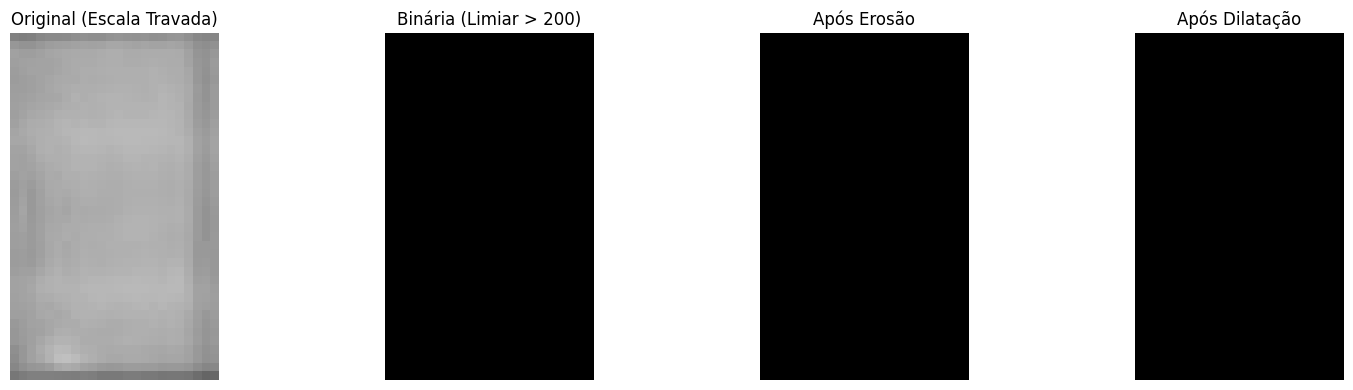

--- Resultados da Análise Clássica ---
✅ Painel Saudável (No-Anomaly). Nenhuma mancha quente significativa.


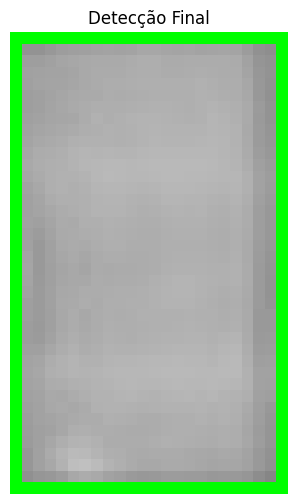

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Selecionando uma imagem aleatória da classe 'Cell' (os pontinhos brilhantes)
amostra = df[df['anomaly_class'] == 'Cell'].sample(1).iloc[0]
caminho_imagem = os.path.join('InfraredSolarModules', amostra['image_filepath'])

# Carregar a imagem em tons de cinza
img_original = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)

# Thresholding
limiar = 200
_, img_binaria = cv2.threshold(img_original, limiar, 255, cv2.THRESH_BINARY)

# Como a imagem tem só 24x40, testei um kernel de 2x2
kernel = np.ones((2, 2), np.uint8)

# Erosão
img_erodida = cv2.erode(img_binaria, kernel, iterations=1)

# Dilatação
img_dilatada = cv2.dilate(img_erodida, kernel, iterations=1)


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titulos = ['Original (Escala Travada)', f'Binária (Limiar > {limiar})', 'Após Erosão', 'Após Dilatação']
imagens = [img_original, img_binaria, img_erodida, img_dilatada]

for ax, img, titulo in zip(axes, imagens, titulos):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(titulo)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Encontrar os contornos na imagem
contornos, hierarquia = cv2.findContours(img_dilatada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# converter a imagem original para colorida (BGR) só pra poder
# desenhar um retângulo vermelho ou verde por cima dela pra visualização
img_resultado = cv2.cvtColor(img_original, cv2.COLOR_GRAY2BGR)

anomalia_detectada = False
area_minima = 5

print("--- Resultados da Análise Clássica ---")

# Analisando cada mancha encontrada
for contorno in contornos:
    area = cv2.contourArea(contorno)

    # Se a mancha for maior que a área mínima --> defeito real
    if area > area_minima:
        anomalia_detectada = True

        # coordenadas (x, y) e o tamanho (largura, altura) da caixa delimitadora
        x, y, w, h = cv2.boundingRect(contorno)

        # Desenha um retângulo vermelho em volta do defeito
        cv2.rectangle(img_resultado, (x, y), (x + w, y + h), (255, 0, 0), 1)

        print(f"Área do defeito: {area} pixels.")

if not anomalia_detectada:
    print("No-Anomaly. Nenhuma mancha quente significativa.")
    # Desenha uma borda verde na imagem toda para indicar que está ok
    cv2.rectangle(img_resultado, (0,0), (img_original.shape[1]-1, img_original.shape[0]-1), (0, 255, 0), 1)

plt.figure(figsize=(4, 6))
plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
plt.title("Detecção Final")
plt.axis('off')
plt.show()

#5 - Matriz de confusão considerando 3 classes

100%|██████████| 20000/20000 [00:04<00:00, 4495.44it/s]



Acurácia geral da Visão Clássica: 48.55%



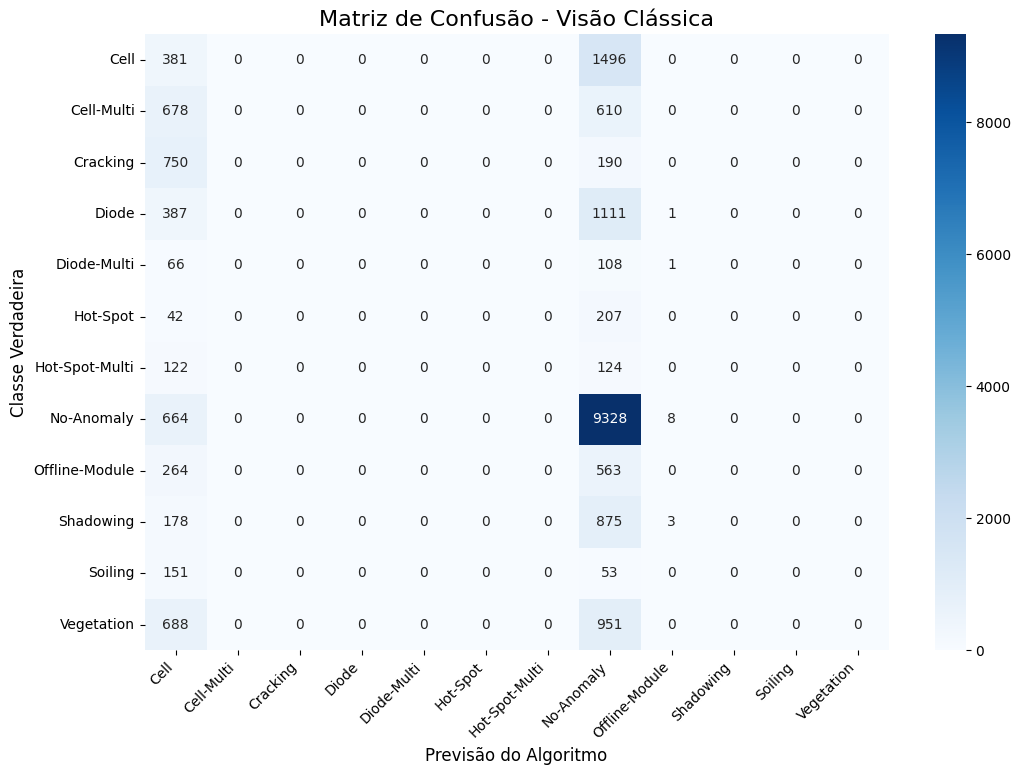

In [7]:
import cv2
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from tqdm import tqdm # barra de progresso

y_verdadeiro = []
y_previsto = []

pasta_raiz = 'InfraredSolarModules'
limiar = 220
kernel = np.ones((2, 2), np.uint8)


# O tqdm cria uma barra de progresso no loop
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    caminho_imagem = os.path.join(pasta_raiz, row['image_filepath'])
    classe_real = row['anomaly_class']

    img_original = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)

    if img_original is None:
        continue

    # 1. Thresholding
    _, img_bin = cv2.threshold(img_original, limiar, 255, cv2.THRESH_BINARY)

    # 2. Morfologia matemática
    img_abertura = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)

    # 3. Extração de contornos
    contornos, _ = cv2.findContours(img_abertura, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Pega a área da maior mancha encontrada na imagem
    maior_area = 0
    if len(contornos) > 0:
        maior_area = max([cv2.contourArea(c) for c in contornos])

    # 4. A regra de classificação simplificada
    if maior_area < 5:
        previsao = 'No-Anomaly'
    elif maior_area > 800:
        previsao = 'Offline-Module'
    else:
        previsao = 'Cell'

    # Salva os resultados
    y_verdadeiro.append(classe_real)
    y_previsto.append(previsao)

# --- AVALIAÇÃO E MÉTRICAS ---
acuracia = accuracy_score(y_verdadeiro, y_previsto)
print(f"\nAcurácia geral da Visão Clássica: {acuracia * 100:.2f}%\n")

# Matriz de confusão
classes_unicas = sorted(list(set(y_verdadeiro)))
matriz = confusion_matrix(y_verdadeiro, y_previsto, labels=classes_unicas)

plt.figure(figsize=(12, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_unicas, yticklabels=classes_unicas)
plt.title('Matriz de Confusão - Visão Clássica', fontsize=16)
plt.ylabel('Classe Verdadeira', fontsize=12)
plt.xlabel('Previsão do Algoritmo', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()